In [7]:
## Import Libraries
import pandas as pd
import numpy as np
import gsw
import PyCO2SYS as pyco2

In [44]:
falkor = pd.read_csv('bottle_data.csv',
                     na_values = [-9,-999]) # need to add na_values so that pyco2sys doesn't try to solve carbonate system with TA=-999
# need to rename columns from BCO-DMO file to match cols in clean_falkor.py
cols = {'STNNBR':'station',
        'CASTNO':'cast',
        'LATITUDE':'lat',
        'LONGITUDE':'lon',
        'CTDPRS':'press',
        'CTDTMP':'temperature',
        'CTDSAL':'sal',
        'CTDS_FLAG_W':'sal_flag',
        'CTDOXY':'O2',
        'CTDOXY_FLAG_W':'O2_flag',
        'FLOR':'fluor',
        'FLOR_FLAG_W':'fluor_flag',
        'NOx_FLAG_W':'NOx_flag',
        'NITRIT_BabLab':'NO2',
        'NITRIT_FLAG_W':'NO2_flag',
        'PHSPHT':'phosphate',
        'PHSPHT_FLAG_W':'phosphate_flag',
        'NH4_FLAG_W':'NH4_flag',
        'PH_TOT':'pH_tot',
        'PH_TOT_FLAG_W':'pH_tot_flag',
        'PH_TEMP':'pH_temp', # how interchangeable is this with CTD temp?
        'TA_FLAG_W':'TA_flag'}
falkor = falkor.rename(columns = cols)

In [45]:
# Select Flagged Bad Data
st2_cast5 = falkor.index[(falkor['station']==2)&(falkor['cast']==5)].tolist()
falkor.loc[st2_cast5, 'sal_flag']=0 # Cast was removed as it was potentially influenced by Hurricane Fabio. No significant impact on the further analysis. 
flag_good = np.array([2,6])
idx_flag = np.where((np.isin(falkor['sal_flag'],flag_good))&(np.isin(falkor['O2_flag'],flag_good))&
(np.isin(falkor['NOx_flag'],flag_good))&(np.isin(falkor['phosphate_flag'],flag_good))&
(np.isin(falkor['NH4_flag'],flag_good))&(np.isin(falkor['pH_tot_flag'],flag_good))&
(np.isin(falkor['TA_flag'],flag_good))&(np.isin(falkor['NO2_flag'],flag_good))&(np.isin(falkor['fluor_flag'],flag_good)))

In [46]:
# Calculate Density 
SA =  gsw.SA_from_SP(falkor['sal'], falkor['press'], falkor['lon'], falkor['lat'])
CT = gsw.CT_from_t(SA, falkor['temperature'], falkor['press'])
falkor['sigma0'] = gsw.density.sigma0(SA, CT)
falkor['rho'] = gsw.density.rho(SA, CT, falkor['press'])

In [47]:
# Calculate Carbonate System 
Z = pyco2.sys(par1 = falkor['TA'], par2 = falkor['pH_tot'], par1_type = 1, par2_type= 3, salinity= falkor['sal'], temperature=25, temperature_out=falkor['temperature'], pressure= 0, pressure_out=falkor['press'],
total_phosphate= falkor['phosphate'], total_ammonia=falkor['NH4'], opt_pH_scale= 1, opt_k_carbonic= 10, opt_total_borate= 2, opt_k_fluoride= 2)
falkor['DIC'] = Z['dic']
falkor['pH_insitu'] = Z['pH_out']

In [48]:
# Remove Bad Data and Save New Vectors
T = np.array(falkor['temperature'])[idx_flag] # degrees C
S = np.array(falkor['sal'])[idx_flag] # psu
P = np.array(falkor['press'])[idx_flag] # dbar
rho = np.array(falkor['rho'])[idx_flag] # kg/m3
sigma0 = np.array(falkor['sigma0'])[idx_flag] # kg/m3 # 
DIC = np.array(falkor['DIC'])[idx_flag] #umol/kg  
DIP = np.array(falkor['phosphate'])[idx_flag]/rho*1000 #umol/kg
NO2 = np.array(falkor['NO2'])[idx_flag]/rho*1000 #umol/kg
NO3 = (np.array(falkor['NOx'])[idx_flag]-np.array(falkor['NO2'])[idx_flag])/rho*1000 #umol/kg
NH4 = np.array(falkor['NH4'])[idx_flag]/rho*1000 #umol/kg
Nstar = (NO2+NO3+NH4)-16*DIP+2.9 # umol/kg  ## Change the DIP coefficient (either 11.4 or 16) for sensitivity analyses. 
TA = np.array(falkor['TA'])[idx_flag] #umol/kg
pH = np.array(falkor['pH_insitu'])[idx_flag] 
O2 = np.array(falkor['O2'])[idx_flag] #umol/kg
station = np.array(falkor['station'])[idx_flag]
cast= np.array(falkor['cast'])[idx_flag]
lat = np.array(falkor['lat'])[idx_flag]
lon = np.array(falkor['lon'])[idx_flag]
pH_tot = np.array(falkor['pH_tot'])[idx_flag]
pH_temp =  np.array(falkor['pH_temp'])[idx_flag]
fluor = np.array(falkor['fluor'])[idx_flag]
falkor_df_data = np.array([station, cast, lat, lon, T, S, P, rho,sigma0, DIC,DIP,NO3, NO2,NH4, Nstar, TA, pH, pH_tot, pH_temp, O2, fluor]).T
falkor_clean= pd.DataFrame(data= falkor_df_data,
                           columns=['Station', 'cast', 'lat', 'lon','T', 'S', 'P', 'rho','sigma0','DIC','DIP','NO3', 'NO2', 'NH4', 'Nstar', 'TA', 'pH', 'pH_tot', 'pH_temp', 'O2',  'fluor'])

In [51]:
# Save the clean version
falkor_clean.to_csv('falkor_clean.csv')

In [50]:
falkor

,CRUISEID,EXPOCODE,station,cast,SAMPNO,DATE,TIME,ISO_DateTime_UTC,lat,lon,...,NH4_flag,pH_tot,pH_tot_flag,pH_temp,TA,TA_flag,sigma0,rho,DIC,pH_insitu
0,FK180624,33FA20180624,1,1,1,30-06-2018,6:30:11,2018-06-30T13:30:11Z,13.99756,-101.99646,...,2,7.353685,2,25,2365.73,2,27.398839,1032.021568,2353.613400,7.579630
1,FK180624,33FA20180624,1,1,2,30-06-2018,6:30:11,2018-06-30T13:30:11Z,13.99696,-101.99638,...,6,7.337197,2,25,2317.43,3,27.258595,1030.739798,2310.576271,7.555480
2,FK180624,33FA20180624,1,1,3,30-06-2018,6:30:11,2018-06-30T13:30:11Z,13.99666,-101.99637,...,2,7.338867,2,25,2341.66,2,27.192531,1030.269528,2334.655036,7.552845
3,FK180624,33FA20180624,1,1,4,30-06-2018,6:30:11,2018-06-30T13:30:11Z,13.99634,-101.99632,...,2,7.348678,2,25,2336.83,2,27.099037,1029.718308,2326.502511,7.557853
4,FK180624,33FA20180624,1,1,5,30-06-2018,6:30:11,2018-06-30T13:30:11Z,13.99590,-101.99632,...,2,7.363535,6,25,2325.23,2,26.951445,1029.102833,2308.999691,7.562778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,FK180624,33FA20180624,19,1,20,13-07-2018,23:11:09,2018-07-14T06:11:09Z,17.99955,-119.00078,...,2,7.812985,2,25,2261.35,2,24.798915,1025.196027,2086.532641,7.931072
523,FK180624,33FA20180624,19,1,21,13-07-2018,23:11:09,2018-07-14T06:11:09Z,17.99953,-119.00073,...,2,7.891521,6,25,2269.19,2,24.285210,1024.635985,2057.787649,7.979194
524,FK180624,33FA20180624,19,1,22,13-07-2018,23:11:09,2018-07-14T06:11:09Z,17.99948,-119.00075,...,2,8.006897,2,25,2285.60,2,23.384373,1023.597482,2010.796026,8.032841
525,FK180624,33FA20180624,19,1,23,13-07-2018,23:11:09,2018-07-14T06:11:09Z,17.99944,-119.00076,...,2,8.019350,2,25,2290.30,2,23.097564,1023.221077,2007.823863,8.030357


In [53]:
import statsmodels.api as sm

In [54]:
# Load Data
falkor = pd.read_csv('falkor_clean.csv')
falkor = falkor[['Station', 'lon', 'lat' ,'T', 'S', 'P', 'O2', 'sigma0', 'rho', 'DIC', 'DIP', 'NO3', 'NO2', 'NH4']]
st = np.array((1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19))
falkor = falkor.iloc[np.isin(falkor['Station'], st)]

In [55]:
falkor

,Station,lon,lat,T,S,P,O2,sigma0,rho,DIC,DIP,NO3,NO2,NH4
0,1.0,-101.99646,13.99756,4.5197,34.5597,1007.273,10.023,27.398839,1032.021568,2353.613400,3.598666,41.301462,0.000000,0.000000
1,1.0,-101.99637,13.99666,6.2323,34.5625,674.359,1.936,27.192531,1030.269528,2334.655036,3.338074,36.154617,0.000000,0.000000
2,1.0,-101.99632,13.99634,6.9636,34.5694,575.667,1.906,27.099037,1029.718308,2326.502511,3.292769,32.519701,0.353367,0.000000
3,1.0,-101.99632,13.99590,8.1096,34.5930,475.147,1.814,26.951445,1029.102833,2308.999691,4.038188,26.433080,0.481626,0.000000
4,1.0,-101.99632,13.99568,9.1312,34.6347,399.990,1.739,26.824040,1028.627207,2305.193182,3.285786,22.660603,0.713269,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,19.0,-119.00078,17.99955,16.7505,33.9801,90.737,157.980,24.798915,1025.196027,2086.532641,0.711781,3.342358,0.124873,0.013867
475,19.0,-119.00073,17.99953,18.9031,33.9934,80.813,198.824,24.285210,1024.635985,2057.787649,0.411791,2.650793,0.062366,0.013087
476,19.0,-119.00075,17.99948,23.1536,34.3255,49.845,211.656,23.384373,1023.597482,2010.796026,0.166196,0.166081,0.000000,0.000000
477,19.0,-119.00076,17.99944,24.1989,34.3532,28.982,207.283,23.097564,1023.221077,2007.823863,0.199071,0.420242,0.000000,0.000000


In [56]:
# Calculate AOU 
SA =  gsw.SA_from_SP(falkor['S'], falkor['P'], falkor['lon'], falkor['lat'])
PT = gsw.pt0_from_t(SA, falkor['T'], falkor['P'])
O2sat = gsw.O2sol_SP_pt(falkor['S'], PT)
AOU = O2sat-falkor['O2']
falkor['AOU'] = AOU 
falkor['DIN'] = falkor['NO3']+falkor['NO2']+falkor['NH4']

In [59]:
# Calculate -O2:P, AOU, C:N:P for different O2 ranges (robust fit)
oxycline = falkor.where((falkor['P']>45)&(falkor['P']<95))
oxycline = oxycline.dropna(axis=0)

In [60]:
# RLM
xx = sm.add_constant(oxycline['DIP'])
rO2 = sm.RLM(oxycline['O2'], xx, M = sm.robust.norms.HuberT()).fit()
rAOU = sm.RLM(oxycline['AOU'], xx, M = sm.robust.norms.HuberT()).fit()
rC = sm.RLM(oxycline['DIC'], xx, M = sm.robust.norms.HuberT()).fit()
rN = sm.RLM(oxycline['DIN'], xx, M = sm.robust.norms.HuberT()).fit()

In [61]:
# Calculate respiration quotient and Cox
Cox1 = round(4-4*(rAOU.params[1]-2*rN.params[1])/rC.params[1],2)
Cox2 = round(4-4*(rAOU.params[1])/rC.params[1],2)

In [62]:
# Print Results
text1 = 'RLS C:N:P is {}+-{} : {}+-{} : 1 (se)'.format(round(rC.params[1],3), round(rC.bse[1],3), round(rN.params[1],3), round(rN.bse[1],3))
text2 = 'RLS AOU:P is {}+-{}'.format(round(rAOU.params[1],3), round(rAOU.bse[1],3))
text3 = 'RLS Cox calculated with AOU:P is {}, and {} with no nitrification'.format(Cox1,Cox2)


print(text1,text2, text3, sep='\n')

RLS C:N:P is 112.486+-4.256 : 11.397+-0.343 : 1 (se)
RLS AOU:P is 107.47+-0.968
RLS Cox calculated with AOU:P is 0.99, and 0.18 with no nitrification


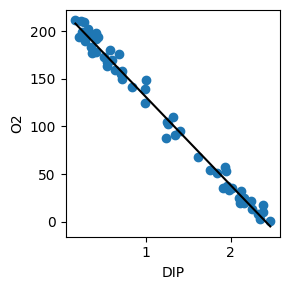

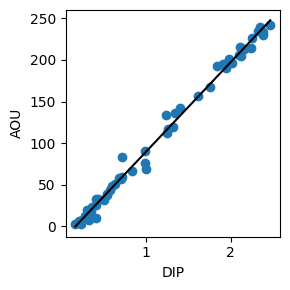

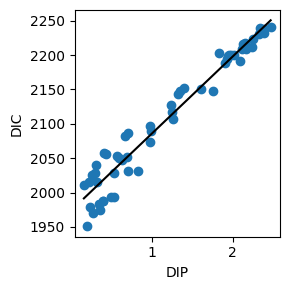

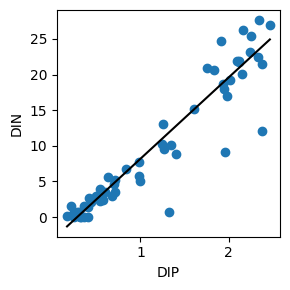

In [82]:
import matplotlib.pyplot as plt
def quickplot(xvar, yvar, regressionparams):   
    fig, ax = plt.subplots(1,1, figsize = (3,3))
    ax.scatter(oxycline[xvar], oxycline[yvar])
    xfit = np.linspace(oxycline[xvar].min(), oxycline[xvar].max())
    ax.plot(xfit, xfit*regressionparams[1]+regressionparams[0], color='k')
    ax.set_xlabel(xvar)
    ax.set_ylabel(yvar)
    plt.tight_layout()
    plt.show()

quickplot('DIP', 'O2', rO2.params)
quickplot('DIP', 'AOU', rAOU.params)
quickplot('DIP', 'DIC', rC.params)
quickplot('DIP', 'DIN', rN.params)

In [83]:
# Set Directory
output_path = 'output/OM_variations/{}'

In [84]:
# Select Method
method = 'redfield_oxidation_states' # select: "experimental", "anderson", "redfield", "oxidation_states" "redfield_oxidation_states"
# Experimental refers to CNP ratio etc calculated in cacl_oxycline_features
# _oxidation states refers to the sensitivity analysis

In [85]:
# Parameters
C = 106
H = 263
O = 110
N = 16
P = 1
O2 = 138
charge = 0
Cox = 0
# Stoichiometry calculations
DNRN_NO3 = round(2*C+0.5*H-O-1.5*N+2.5*P,2)
DNRN_NO2 = DNRN_NO3
DNRN_water = round(0.5*H-1.5*N-1.5*P,2)
denit_NO2 = round(4/3*C+1/3*H-2/3*O-N+5/3*P,2)
denit_N2 = round(2/3*C+1/6*H-1/3*O-0.5*N+5/6*P,2)
denit_water = round(2/3*C+2/3*H-1/3*O-2*N-2/3*P,2)
reactions = ['OM C:H:O:N:P ratio is {}:{}:{}:{}:{}'.format(C,H,O,N,P), 
            'DNRN: OM + {} NO3- + {} H+ -> {} CO2 + {} NH4+ + {} H3PO4 + {} NO2- + {} H20'.format(DNRN_NO3, N, C, N, P, DNRN_NO2, DNRN_water),
            'Denitrification: OM + {} NO2- + {}  H+ -> {} CO2 + {} NH4+ + {} H3PO4 + {} N2 + {} H2O'.format(denit_NO2,denit_NO2+N, C, N, P, denit_N2, denit_water)]

In [88]:
with open(output_path.format('redfield/reactions.txt'), 'w') as f:
        f.write('\n'.join(reactions))

In [89]:
# R Matrix
R_DNRN_NO3 = -DNRN_NO3/C
R_DNRN_NO2 = DNRN_NO2/C
R_DNRN_NH4 = N/C
R_DNRN_Nstar = (-DNRN_NO3+DNRN_NO2+N-16*P)/C
R_DNRN_TA = (N-P)/C
R_denit_NO2 = -denit_NO2/C
R_denit_NH4 = N/C
R_denit_Nstar = (-denit_NO2+N-16*P)/C
R_denit_TA = (denit_NO2+N-P)/C
R = np.array([(R_DNRN_NO3, R_DNRN_NO2,R_DNRN_NH4,R_DNRN_Nstar,R_DNRN_TA,1),
                (0, R_denit_NO2,R_denit_NH4,R_denit_Nstar,R_denit_TA,1),
                (2.909,-12,-9.091,-18.182,0.182,-1),
                (46.296, -46.296,0,0,0,-1),
                (0,0,0,0,2,1) ], dtype=float).T 
np.savetxt(output_path.format('redfield/R.txt'), R, delimiter=',')
print('done')

done


In [90]:
round(np.pi, 2)

3.14